This notebook contains sentiment labeling results from crawling data via Playstore about “Roblox” in Indonesia, as well as machine learning model training for sentiment analysis.
by Ifan Hakim

# Gathering Library

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
import tensorflow as tf

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ReduceLROnPlateau

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Embedding, Dropout, SpatialDropout1D, Bidirectional, LSTM, Conv1D, GlobalMaxPooling1D

# Import the Dataset

In [132]:
data_mentah = 'roblox_playstore1.csv', 'roblox_playstore2.csv', 'roblox_playstore3.csv', 'roblox_playstore4.csv', 'roblox_playstore5.csv'

all_dataframes = []
for i in data_mentah:
  dataframe = pd.read_csv(i)
  all_dataframes.append(dataframe)

df = pd.concat(all_dataframes, ignore_index=True)
df = df.sample(frac=1).reset_index(drop=True)
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,9b163252-69ad-4b35-a679-eb7515889170,dinsamton Elson,https://play-lh.googleusercontent.com/a/ACg8oc...,bruh greedy as hell why do you even want chat ...,1,0,2.711.876,2026-04-04 09:35:04,NaN,NaN,2.711.876
1,b93e4b15-fb94-4404-9fb8-7fd56a786406,alice nepton,https://play-lh.googleusercontent.com/a-/ALV-U...,"most updates now are kinda getting bad now, ye...",3,0,2.714.1096,2026-04-03 00:15:36,NaN,NaN,2.714.1096
2,346de55a-6c38-4dc4-b015-b8b6ea45d8d4,Farid Uddin,https://play-lh.googleusercontent.com/a/ACg8oc...,best,4,0,2.711.876,2026-03-21 18:48:22,NaN,NaN,2.711.876
3,25668870-e834-49e1-acdd-c30666554f39,Tinky Winky,https://play-lh.googleusercontent.com/a-/ALV-U...,JUST CHANGE MY ACCOUNT LOCATION ALREADY CHUCKL...,1,1,2.715.1115,2026-04-04 13:57:21,NaN,NaN,2.715.1115
4,4d193d21-bf26-4c09-be7b-7b14c2f48c24,Nomalungelo Jula,https://play-lh.googleusercontent.com/a/ACg8oc...,Can you please make it faster to load it Like ...,4,1,2.714.1096,2026-04-01 06:36:01,NaN,NaN,2.714.1096
...,...,...,...,...,...,...,...,...,...,...,...
10055,94e38110-77c7-4e25-a287-c80e3006048b,Marivic Quiapos,https://play-lh.googleusercontent.com/a/ACg8oc...,In the Philippines the Philippine government g...,3,0,2.711.876,2026-03-23 01:13:57,NaN,NaN,2.711.876
10056,cad5a74e-dd30-4ac0-8016-6066d6965b00,Yanhong Lei,https://play-lh.googleusercontent.com/a/ACg8oc...,the updates are buns 💔,3,0,2.714.1096,2026-04-02 20:03:05,NaN,NaN,2.714.1096
10057,f169637a-311f-4e1d-8cb9-5d4a8fd7b842,M T IQBAL,https://play-lh.googleusercontent.com/a/ACg8oc...,why every month a upgrade if we will not upgra...,3,0,2.711.876,2026-03-19 18:19:50,NaN,NaN,2.711.876
10058,91acbbe2-b490-49a0-ace2-7570f5a50cb4,Musa,https://play-lh.googleusercontent.com/a/ACg8oc...,I like a roblox 😁,5,0,2.711.876,2026-04-05 12:44:23,NaN,NaN,2.711.876


# Preprocessing Data

In [133]:
# Check duplicated data that contains in Dataframe
total_duplicate = df.duplicated().sum()
print(f"Total duplicated data: {total_duplicate}")

Total duplicated data: 0


In [134]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
reviewId                    0
userName                    0
userImage                   0
content                     1
score                       0
thumbsUpCount               0
reviewCreatedVersion     2163
at                          0
replyContent            10060
repliedAt               10060
appVersion               2163
dtype: int64


In [135]:
columns_to_drop = ['reviewCreatedVersion', 'replyContent', 'repliedAt', 'appVersion']
df = df.drop(columns=columns_to_drop)
df['content'] = df['content'].fillna('Overall good')
check_missing_values = df.isnull().sum()
print(check_missing_values)
df

reviewId         0
userName         0
userImage        0
content          0
score            0
thumbsUpCount    0
at               0
dtype: int64


,reviewId,userName,userImage,content,score,thumbsUpCount,at
0,9b163252-69ad-4b35-a679-eb7515889170,dinsamton Elson,https://play-lh.googleusercontent.com/a/ACg8oc...,bruh greedy as hell why do you even want chat ...,1,0,2026-04-04 09:35:04
1,b93e4b15-fb94-4404-9fb8-7fd56a786406,alice nepton,https://play-lh.googleusercontent.com/a-/ALV-U...,"most updates now are kinda getting bad now, ye...",3,0,2026-04-03 00:15:36
2,346de55a-6c38-4dc4-b015-b8b6ea45d8d4,Farid Uddin,https://play-lh.googleusercontent.com/a/ACg8oc...,best,4,0,2026-03-21 18:48:22
3,25668870-e834-49e1-acdd-c30666554f39,Tinky Winky,https://play-lh.googleusercontent.com/a-/ALV-U...,JUST CHANGE MY ACCOUNT LOCATION ALREADY CHUCKL...,1,1,2026-04-04 13:57:21
4,4d193d21-bf26-4c09-be7b-7b14c2f48c24,Nomalungelo Jula,https://play-lh.googleusercontent.com/a/ACg8oc...,Can you please make it faster to load it Like ...,4,1,2026-04-01 06:36:01
...,...,...,...,...,...,...,...
10055,94e38110-77c7-4e25-a287-c80e3006048b,Marivic Quiapos,https://play-lh.googleusercontent.com/a/ACg8oc...,In the Philippines the Philippine government g...,3,0,2026-03-23 01:13:57
10056,cad5a74e-dd30-4ac0-8016-6066d6965b00,Yanhong Lei,https://play-lh.googleusercontent.com/a/ACg8oc...,the updates are buns 💔,3,0,2026-04-02 20:03:05
10057,f169637a-311f-4e1d-8cb9-5d4a8fd7b842,M T IQBAL,https://play-lh.googleusercontent.com/a/ACg8oc...,why every month a upgrade if we will not upgra...,3,0,2026-03-19 18:19:50
10058,91acbbe2-b490-49a0-ace2-7570f5a50cb4,Musa,https://play-lh.googleusercontent.com/a/ACg8oc...,I like a roblox 😁,5,0,2026-04-05 12:44:23


In [136]:
nltk.download("vader_lexicon")
nltk.download('omw-1.4')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [137]:
def cleaningText(text):
  text = re.sub(r"@[A-Za-z0-9]+", "", text) # remove add
  text = re.sub(r"#[A-Za-z0-9]+", "", text)  # remove hashtag
  text = re.sub(r"http\S+", "", text)  # remove link
  text = re.sub(r"[0-9]+", "", text) # remove number
  text = re.sub(r"[^\w\s]", "", text) # remove character other than words and number
  text = re.sub(r"[^\x00-\x7F]+", "", text) # remove non-ASCII characters

  text = text.replace("\n", " ") # remove newline
  text = text.replace("\r", "") # remove carriage return characters
  text = text.translate(str.maketrans("", "", string.punctuation)) # remove punctuation
  text = text.strip(" ") # remove
  return text

def casefoldingText(text):
  text = text.lower()
  return text

In [138]:
# Clean text
df["cleaned_text"] = df["content"].apply(cleaningText)

# Lower text
df["final_text"] = df["cleaned_text"].apply(casefoldingText)

df

,reviewId,userName,userImage,content,score,thumbsUpCount,at,cleaned_text,final_text
0,9b163252-69ad-4b35-a679-eb7515889170,dinsamton Elson,https://play-lh.googleusercontent.com/a/ACg8oc...,bruh greedy as hell why do you even want chat ...,1,0,2026-04-04 09:35:04,bruh greedy as hell why do you even want chat ...,bruh greedy as hell why do you even want chat ...
1,b93e4b15-fb94-4404-9fb8-7fd56a786406,alice nepton,https://play-lh.googleusercontent.com/a-/ALV-U...,"most updates now are kinda getting bad now, ye...",3,0,2026-04-03 00:15:36,most updates now are kinda getting bad now yes...,most updates now are kinda getting bad now yes...
2,346de55a-6c38-4dc4-b015-b8b6ea45d8d4,Farid Uddin,https://play-lh.googleusercontent.com/a/ACg8oc...,best,4,0,2026-03-21 18:48:22,best,best
3,25668870-e834-49e1-acdd-c30666554f39,Tinky Winky,https://play-lh.googleusercontent.com/a-/ALV-U...,JUST CHANGE MY ACCOUNT LOCATION ALREADY CHUCKL...,1,1,2026-04-04 13:57:21,JUST CHANGE MY ACCOUNT LOCATION ALREADY CHUCKL...,just change my account location already chuckl...
4,4d193d21-bf26-4c09-be7b-7b14c2f48c24,Nomalungelo Jula,https://play-lh.googleusercontent.com/a/ACg8oc...,Can you please make it faster to load it Like ...,4,1,2026-04-01 06:36:01,Can you please make it faster to load it Like ...,can you please make it faster to load it like ...
...,...,...,...,...,...,...,...,...,...
10055,94e38110-77c7-4e25-a287-c80e3006048b,Marivic Quiapos,https://play-lh.googleusercontent.com/a/ACg8oc...,In the Philippines the Philippine government g...,3,0,2026-03-23 01:13:57,In the Philippines the Philippine government g...,in the philippines the philippine government g...
10056,cad5a74e-dd30-4ac0-8016-6066d6965b00,Yanhong Lei,https://play-lh.googleusercontent.com/a/ACg8oc...,the updates are buns 💔,3,0,2026-04-02 20:03:05,the updates are buns,the updates are buns
10057,f169637a-311f-4e1d-8cb9-5d4a8fd7b842,M T IQBAL,https://play-lh.googleusercontent.com/a/ACg8oc...,why every month a upgrade if we will not upgra...,3,0,2026-03-19 18:19:50,why every month a upgrade if we will not upgra...,why every month a upgrade if we will not upgra...
10058,91acbbe2-b490-49a0-ace2-7570f5a50cb4,Musa,https://play-lh.googleusercontent.com/a/ACg8oc...,I like a roblox 😁,5,0,2026-04-05 12:44:23,I like a roblox,i like a roblox


# Labeling the Datasets

In [139]:
def labeling(row):
    compound = row['compound_score']
    if compound >= 0.05:
        return "positive"
    elif compound <= -0.05:
        return "negative"
    else:
        return "neutral"

In [140]:
sid = SentimentIntensityAnalyzer()

texts = df["final_text"]

compound_score = []

for text in texts:
  sentiment_scores = sid.polarity_scores(text)
  compound_score.append(sentiment_scores["compound"])

df["compound_score"] = compound_score

df

,reviewId,userName,userImage,content,score,thumbsUpCount,at,cleaned_text,final_text,compound_score
0,9b163252-69ad-4b35-a679-eb7515889170,dinsamton Elson,https://play-lh.googleusercontent.com/a/ACg8oc...,bruh greedy as hell why do you even want chat ...,1,0,2026-04-04 09:35:04,bruh greedy as hell why do you even want chat ...,bruh greedy as hell why do you even want chat ...,0.1613
1,b93e4b15-fb94-4404-9fb8-7fd56a786406,alice nepton,https://play-lh.googleusercontent.com/a-/ALV-U...,"most updates now are kinda getting bad now, ye...",3,0,2026-04-03 00:15:36,most updates now are kinda getting bad now yes...,most updates now are kinda getting bad now yes...,-0.6118
2,346de55a-6c38-4dc4-b015-b8b6ea45d8d4,Farid Uddin,https://play-lh.googleusercontent.com/a/ACg8oc...,best,4,0,2026-03-21 18:48:22,best,best,0.6369
3,25668870-e834-49e1-acdd-c30666554f39,Tinky Winky,https://play-lh.googleusercontent.com/a-/ALV-U...,JUST CHANGE MY ACCOUNT LOCATION ALREADY CHUCKL...,1,1,2026-04-04 13:57:21,JUST CHANGE MY ACCOUNT LOCATION ALREADY CHUCKL...,just change my account location already chuckl...,0.0000
4,4d193d21-bf26-4c09-be7b-7b14c2f48c24,Nomalungelo Jula,https://play-lh.googleusercontent.com/a/ACg8oc...,Can you please make it faster to load it Like ...,4,1,2026-04-01 06:36:01,Can you please make it faster to load it Like ...,can you please make it faster to load it like ...,0.9485
...,...,...,...,...,...,...,...,...,...,...
10055,94e38110-77c7-4e25-a287-c80e3006048b,Marivic Quiapos,https://play-lh.googleusercontent.com/a/ACg8oc...,In the Philippines the Philippine government g...,3,0,2026-03-23 01:13:57,In the Philippines the Philippine government g...,in the philippines the philippine government g...,0.5927
10056,cad5a74e-dd30-4ac0-8016-6066d6965b00,Yanhong Lei,https://play-lh.googleusercontent.com/a/ACg8oc...,the updates are buns 💔,3,0,2026-04-02 20:03:05,the updates are buns,the updates are buns,0.0000
10057,f169637a-311f-4e1d-8cb9-5d4a8fd7b842,M T IQBAL,https://play-lh.googleusercontent.com/a/ACg8oc...,why every month a upgrade if we will not upgra...,3,0,2026-03-19 18:19:50,why every month a upgrade if we will not upgra...,why every month a upgrade if we will not upgra...,-0.2584
10058,91acbbe2-b490-49a0-ace2-7570f5a50cb4,Musa,https://play-lh.googleusercontent.com/a/ACg8oc...,I like a roblox 😁,5,0,2026-04-05 12:44:23,I like a roblox,i like a roblox,0.3612


In [141]:
df["label"] = df.apply(labeling, axis=1)
df["label"].value_counts()
df

,reviewId,userName,userImage,content,score,thumbsUpCount,at,cleaned_text,final_text,compound_score,label
0,9b163252-69ad-4b35-a679-eb7515889170,dinsamton Elson,https://play-lh.googleusercontent.com/a/ACg8oc...,bruh greedy as hell why do you even want chat ...,1,0,2026-04-04 09:35:04,bruh greedy as hell why do you even want chat ...,bruh greedy as hell why do you even want chat ...,0.1613,positive
1,b93e4b15-fb94-4404-9fb8-7fd56a786406,alice nepton,https://play-lh.googleusercontent.com/a-/ALV-U...,"most updates now are kinda getting bad now, ye...",3,0,2026-04-03 00:15:36,most updates now are kinda getting bad now yes...,most updates now are kinda getting bad now yes...,-0.6118,negative
2,346de55a-6c38-4dc4-b015-b8b6ea45d8d4,Farid Uddin,https://play-lh.googleusercontent.com/a/ACg8oc...,best,4,0,2026-03-21 18:48:22,best,best,0.6369,positive
3,25668870-e834-49e1-acdd-c30666554f39,Tinky Winky,https://play-lh.googleusercontent.com/a-/ALV-U...,JUST CHANGE MY ACCOUNT LOCATION ALREADY CHUCKL...,1,1,2026-04-04 13:57:21,JUST CHANGE MY ACCOUNT LOCATION ALREADY CHUCKL...,just change my account location already chuckl...,0.0000,neutral
4,4d193d21-bf26-4c09-be7b-7b14c2f48c24,Nomalungelo Jula,https://play-lh.googleusercontent.com/a/ACg8oc...,Can you please make it faster to load it Like ...,4,1,2026-04-01 06:36:01,Can you please make it faster to load it Like ...,can you please make it faster to load it like ...,0.9485,positive
...,...,...,...,...,...,...,...,...,...,...,...
10055,94e38110-77c7-4e25-a287-c80e3006048b,Marivic Quiapos,https://play-lh.googleusercontent.com/a/ACg8oc...,In the Philippines the Philippine government g...,3,0,2026-03-23 01:13:57,In the Philippines the Philippine government g...,in the philippines the philippine government g...,0.5927,positive
10056,cad5a74e-dd30-4ac0-8016-6066d6965b00,Yanhong Lei,https://play-lh.googleusercontent.com/a/ACg8oc...,the updates are buns 💔,3,0,2026-04-02 20:03:05,the updates are buns,the updates are buns,0.0000,neutral
10057,f169637a-311f-4e1d-8cb9-5d4a8fd7b842,M T IQBAL,https://play-lh.googleusercontent.com/a/ACg8oc...,why every month a upgrade if we will not upgra...,3,0,2026-03-19 18:19:50,why every month a upgrade if we will not upgra...,why every month a upgrade if we will not upgra...,-0.2584,negative
10058,91acbbe2-b490-49a0-ace2-7570f5a50cb4,Musa,https://play-lh.googleusercontent.com/a/ACg8oc...,I like a roblox 😁,5,0,2026-04-05 12:44:23,I like a roblox,i like a roblox,0.3612,positive


In [142]:
# Label Encoding
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["label"])
df["label_encoded"].value_counts()

,count
label_encoded,
2,5209
0,3005
1,1846


In [143]:
df.to_csv("/content/roblox_sentiment.csv", index=False)

# Function for Modeling

In [144]:
def accuracy(model, X_train_data, X_test_data, y_train_data, y_test_data):
  # Get raw predictions
  y_pred_train_raw = model.predict(X_train_data)
  y_pred_raw = model.predict(X_test_data)

  if len(y_pred_train_raw.shape) > 1 and y_pred_train_raw.shape[1] > 1:
      y_pred_train = np.argmax(y_pred_train_raw, axis=1)
      y_pred = np.argmax(y_pred_raw, axis=1)
      y_train_data_compare = le.transform(y_train_data)
      y_test_data_compare = le.transform(y_test_data)
  else:
      y_pred_train = y_pred_train_raw
      y_pred = y_pred_raw
      y_train_data_compare = y_train_data
      y_test_data_compare = y_test_data

  accuracy_train = accuracy_score(y_train_data_compare, y_pred_train)
  accuracy_test = accuracy_score(y_test_data_compare, y_pred)

  print("train accuracy: ", accuracy_train)
  print("test accuracy: ", accuracy_test)

In [145]:
def accuracy_value(model, X_train_data, X_test_data, y_train_data, y_test_data):
  # Get raw predictions
  y_pred_train_raw = model.predict(X_train_data)
  y_pred_raw = model.predict(X_test_data)

  if len(y_pred_train_raw.shape) > 1 and y_pred_train_raw.shape[1] > 1:
      y_pred_train = np.argmax(y_pred_train_raw, axis=1)
      y_pred = np.argmax(y_pred_raw, axis=1)
      y_train_data_compare = le.transform(y_train_data)
      y_test_data_compare = le.transform(y_test_data)
  else:
      y_pred_train = y_pred_train_raw
      y_pred = y_pred_raw
      y_train_data_compare = y_train_data
      y_test_data_compare = y_test_data

  accuracy_train = accuracy_score(y_train_data_compare, y_pred_train)
  accuracy_test = accuracy_score(y_test_data_compare, y_pred)

  return accuracy_train, accuracy_test

In [146]:
def evaluate_deep_learning_model(model, history, X_test, y_test, label_encoder, model_name="Model"):
    print(f"\n       EVALUASI {model_name.upper()}       \n")

    # VISUALISASI GRAFIK TRAINING (Accuracy & Loss)
    plt.figure(figsize=(14, 5))

    # Plot Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
    plt.title(f'Kurva Akurasi - {model_name}', fontsize=14)
    plt.ylabel('Akurasi')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
    plt.title(f'Kurva Loss - {model_name}', fontsize=14)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # EVALUASI SKOR TESTING
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"    - Final Test Loss     : {test_loss:.4f}")
    print(f"    - Final Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)\n")

    # CLASSIFICATION REPORT & CONFUSION MATRIX
    # Melakukan prediksi
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # Mengambil nama kelas asli dari LabelEncoder
    target_names = label_encoder.classes_

    # Print Classification Report
    print("\n" + classification_report(y_test, y_pred, target_names=target_names))

    # Visualisasi Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names,
                annot_kws={"size": 12})
    plt.title(f'Confusion Matrix - {model_name}', pad=20, fontsize=14)
    plt.ylabel('Label Sebenarnya (Actual)', fontsize=12)
    plt.xlabel('Label Prediksi (Predicted)', fontsize=12)
    plt.show()
    print("\n\n")

In [147]:
def plot_model_comparison(comparison_data):
    """
    Fungsi untuk menampilkan tabel dan grafik perbandingan antar model.
    comparison_data: list of dictionary berisi nama model, akurasi train, dan akurasi test
    """
    # Buat DataFrame dari data
    df_compare = pd.DataFrame(comparison_data)

    print("             TABEL PERBANDINGAN SKENARIO              ")
    display(df_compare)
    print("\n")

    # Persiapan Visualisasi Bar Chart
    labels = df_compare['Skenario']
    train_acc = df_compare['Train Accuracy']
    test_acc = df_compare['Test Accuracy']

    x = np.arange(len(labels))  # Lokasi label
    width = 0.35  # Lebar batang

    fig, ax = plt.subplots(figsize=(10, 6))

    # Gambar Batang (Bar)
    rects1 = ax.bar(x - width/2, train_acc, width, label='Train Accuracy', color='#4C72B0')
    rects2 = ax.bar(x + width/2, test_acc, width, label='Test Accuracy', color='#DD8452')

    # Tambahkan Teks, Label, dan Judul
    ax.set_ylabel('Akurasi', fontsize=12)
    ax.set_title('Perbandingan Akurasi Training vs Testing Tiap Skenario', fontsize=14, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.legend(loc='lower right', fontsize=11)

    # Garis Target
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.text(-0.4, 0.86, 'Target 85%', color='red', fontsize=10, fontweight='bold')

    ax.axhline(y=0.92, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.text(-0.4, 0.93, 'Target 92%', color='green', fontsize=10, fontweight='bold')

    # Fungsi untuk menambahkan teks angka di atas bar
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 poin vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10)

    autolabel(rects1)
    autolabel(rects2)

    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# SKENARIO 1: Bi-LSTM (80/20)

In [172]:
df_s1 = df.copy()
df_s1['final_text'] = df_s1['final_text'].fillna('neutral')

# SPLIT DATA 80/20
X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    df_s1['final_text'],
    df_s1["label_encoded"],
    test_size=0.2,
    random_state=123,
    stratify=df_s1["label_encoded"]
)

# TOKENIZER
max_vocab = 3000
max_length = 50

tok_s1 = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tok_s1.fit_on_texts(X_train_s1)

X_train_pad_s1 = pad_sequences(tok_s1.texts_to_sequences(X_train_s1), maxlen=max_length, padding='post', truncating='post')
X_test_pad_s1 = pad_sequences(tok_s1.texts_to_sequences(X_test_s1), maxlen=max_length, padding='post', truncating='post')

# MODEL Bi-LSTM
model_bilstm = Sequential([
    Embedding(input_dim=max_vocab, output_dim=64, input_length=max_length),
    SpatialDropout1D(0.4),
    Bidirectional(LSTM(32, return_sequences=False, dropout=0.3)),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model_bilstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

rlp_s1 = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

# CALLBACKS
es_s1 = EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True)
mc_s1 = ModelCheckpoint(filepath='best_bilstm.h5', mode='max', monitor='val_accuracy', save_best_only=True)

# TRAINING
history_s1 = model_bilstm.fit(
    X_train_pad_s1, y_train_s1, epochs=30, batch_size=64,
    validation_data=(X_test_pad_s1, y_test_s1),
    callbacks=[es_s1, mc_s1, rlp_s1], verbose=1
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5036 - loss: 1.0036

126/126 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - accuracy: 0.5480 - loss: 0.9294 - val_accuracy: 0.6397 - val_loss: 0.7488 - learning_rate: 0.0010
Epoch 2/30
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6788 - loss: 0.7187

126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.7117 - loss: 0.6724 - val_accuracy: 0.7813 - val_loss: 0.5408 - learning_rate: 0.0010
Epoch 3/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8015 - loss: 0.5142

...

126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.8813 - loss: 0.3605 - val_accuracy: 0.8484 - val_loss: 0.4110 - learning_rate: 0.0010
Epoch 6/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.8936 - loss: 0.3274 - val_accuracy: 0.8434 - val_loss: 0.4170 - learning_rate: 0.0010
Epoch 7/30
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9050 - loss: 0.3044
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.9027 - loss: 0.3098 - val_accuracy: 0.8424 - val_loss: 0.4331 - learning_rate: 0.0010
Epoch 8/30
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9156 - loss: 0.2736

126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9163 - loss: 0.2733 - val_accuracy: 0.8549 - val_loss: 0.4343 - learning_rate: 5.0000e-04
Epoch 9/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.9221 - loss: 0.2569 - val_accuracy: 0.8539 - val_loss: 0.4297 - learning_rate: 5.0000e-04
Epoch 10/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9300 - loss: 0.2363
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9251 - loss: 0.2450 - val_accuracy: 0.8529 - val_loss: 0.4462 - learning_rate: 5.0000e-04
Epoch 11/30
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9305 - loss: 0.2400

126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.9350 - loss: 0.2323 - val_accuracy: 0.8559 - val_loss: 0.4604 - learning_rate: 2.5000e-04
Epoch 12/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 12s 56ms/step - accuracy: 0.9344 - loss: 0.2232 - val_accuracy: 0.8519 - val_loss: 0.4602 - learning_rate: 2.5000e-04
Epoch 13/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9362 - loss: 0.2056

126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.9365 - loss: 0.2121 - val_accuracy: 0.8569 - val_loss: 0.4706 - learning_rate: 2.5000e-04
Epoch 14/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9385 - loss: 0.2120 - val_accuracy: 0.8464 - val_loss: 0.4924 - learning_rate: 2.5000e-04
Epoch 15/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9402 - loss: 0.2009
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.9386 - loss: 0.2037 - val_accuracy: 0.8539 - val_loss: 0.4821 - learning_rate: 2.5000e-04
Epoch 16/30
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9486 - loss: 0.1882

126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.9417 - loss: 0.2026 - val_accuracy: 0.8598 - val_loss: 0.4835 - learning_rate: 1.2500e-04
Epoch 17/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9430 - loss: 0.1972 - val_accuracy: 0.8569 - val_loss: 0.4894 - learning_rate: 1.2500e-04
Epoch 18/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9506 - loss: 0.1804
Epoch 18: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.9455 - loss: 0.1892 - val_accuracy: 0.8574 - val_loss: 0.4951 - learning_rate: 1.2500e-04
Epoch 19/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9421 - loss: 0.1996 - val_accuracy: 0.8529 - val_loss: 0.5048 - learning_rate: 6.2500e-05
Epoch 20/30
125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9440 - loss: 0.1978
Epoch 20: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.9459 -


       EVALUASI SKENARIO 1: BI-LSTM       



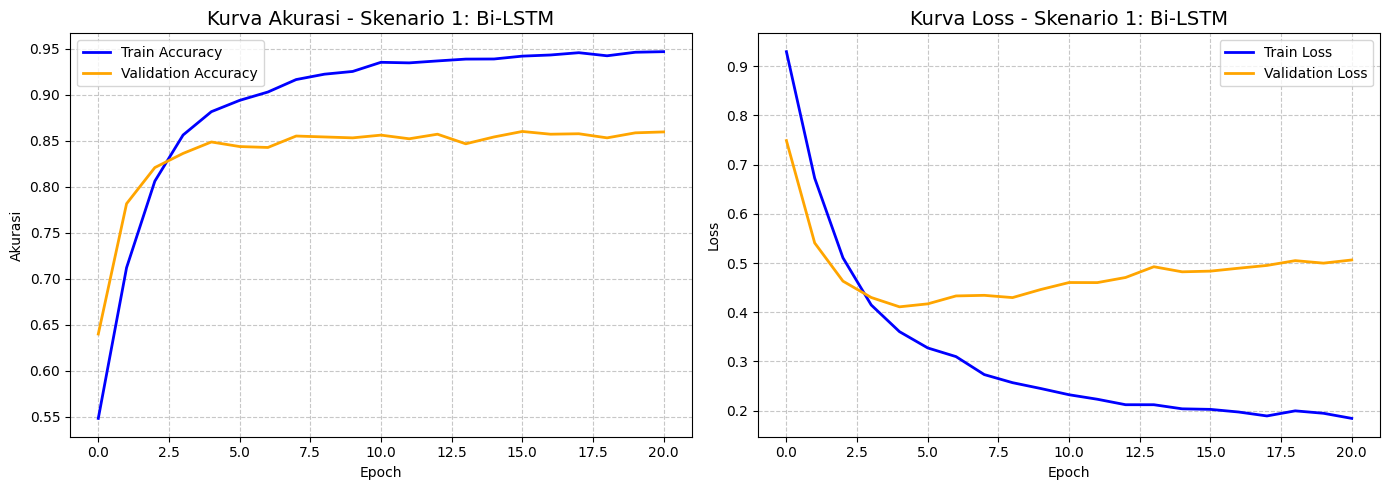

    - Final Test Loss     : 0.4835
    - Final Test Accuracy : 0.8598 (85.98%)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step

              precision    recall  f1-score   support

    negative       0.78      0.83      0.80       601
     neutral       0.91      0.85      0.88       369
    positive       0.89      0.88      0.89      1042

    accuracy                           0.86      2012
   macro avg       0.86      0.85      0.86      2012
weighted avg       0.86      0.86      0.86      2012



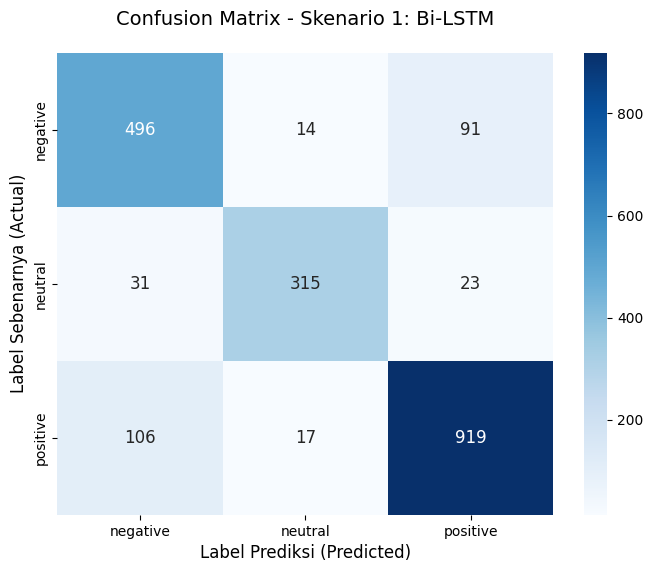

In [173]:
evaluate_deep_learning_model(
    model=model_bilstm,
    history=history_s1,
    X_test=X_test_pad_s1,
    y_test=y_test_s1,
    label_encoder=le,
    model_name="Skenario 1: Bi-LSTM"
)

# SKENARIO 2: GRU (70/30)



In [174]:
df_s2 = df.copy()
df_s2['final_text'] = df_s2['final_text'].fillna('neutral')

# SPLIT DATA 70/30
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
    df_s2['final_text'],
    df_s2["label_encoded"],
    test_size=0.3,
    random_state=123,
    stratify=df_s2["label_encoded"]
)

# TOKENIZER
tok_s2 = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tok_s2.fit_on_texts(X_train_s2)

X_train_pad_s2 = pad_sequences(tok_s2.texts_to_sequences(X_train_s2), maxlen=max_length, padding='post', truncating='post')
X_test_pad_s2 = pad_sequences(tok_s2.texts_to_sequences(X_test_s2), maxlen=max_length, padding='post', truncating='post')

# MODEL GRU
model_gru = Sequential([
    Embedding(input_dim=max_vocab, output_dim=64, input_length=max_length),
    SpatialDropout1D(0.4),
    GRU(64, activation='tanh', dropout=0.3),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model_gru.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

rlp_s2 = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

# CALLBACKS
es_s2 = EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True)
mc_s2 = ModelCheckpoint(filepath='best_gru.h5', monitor='val_accuracy', mode='max', save_best_only=True)

# TRAINING
history_s2 = model_gru.fit(
    X_train_pad_s2, y_train_s2, epochs=30, batch_size=64,
    validation_data=(X_test_pad_s2, y_test_s2),
    callbacks=[es_s2, mc_s2, rlp_s2], verbose=1
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4957 - loss: 1.0420

111/111 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.5138 - loss: 1.0266 - val_accuracy: 0.5179 - val_loss: 1.0083 - learning_rate: 0.0010
Epoch 2/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.5131 - loss: 1.0022 - val_accuracy: 0.5179 - val_loss: 0.9761 - learning_rate: 0.0010
Epoch 3/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5182 - loss: 0.9847

111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.5251 - loss: 0.9544 - val_accuracy: 0.5981 - val_loss: 0.8542 - learning_rate: 0.0010
Epoch 4/30
110/111 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6057 - loss: 0.8345

...

111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9202 - loss: 0.2504 - val_accuracy: 0.8463 - val_loss: 0.4622 - learning_rate: 0.0010
Epoch 13/30
110/111 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9363 - loss: 0.2127

111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.9341 - loss: 0.2176 - val_accuracy: 0.8469 - val_loss: 0.4761 - learning_rate: 0.0010
Epoch 14/30
110/111 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9336 - loss: 0.2173

111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9338 - loss: 0.2158 - val_accuracy: 0.8539 - val_loss: 0.4858 - learning_rate: 0.0010
Epoch 15/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.9433 - loss: 0.1897 - val_accuracy: 0.8539 - val_loss: 0.4975 - learning_rate: 0.0010
Epoch 16/30
110/111 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9506 - loss: 0.1716
Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9453 - loss: 0.1855 - val_accuracy: 0.8519 - val_loss: 0.4882 - learning_rate: 0.0010
Epoch 17/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9543 - loss: 0.1605

111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9517 - loss: 0.1627 - val_accuracy: 0.8542 - val_loss: 0.5057 - learning_rate: 5.0000e-04
Epoch 18/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.9521 - loss: 0.1640 - val_accuracy: 0.8502 - val_loss: 0.5030 - learning_rate: 5.0000e-04
Epoch 19/30
110/111 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9556 - loss: 0.1546
Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9558 - loss: 0.1519 - val_accuracy: 0.8492 - val_loss: 0.5386 - learning_rate: 5.0000e-04
Epoch 20/30
110/111 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9589 - loss: 0.1475

111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.9568 - loss: 0.1477 - val_accuracy: 0.8585 - val_loss: 0.5307 - learning_rate: 2.5000e-04
Epoch 21/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9595 - loss: 0.1420 - val_accuracy: 0.8559 - val_loss: 0.5259 - learning_rate: 2.5000e-04
Epoch 22/30
110/111 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9609 - loss: 0.1325
Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.9592 - loss: 0.1383 - val_accuracy: 0.8555 - val_loss: 0.5388 - learning_rate: 2.5000e-04
Epoch 23/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9621 - loss: 0.1332 - val_accuracy: 0.8555 - val_loss: 0.5369 - learning_rate: 1.2500e-04
Epoch 24/30
110/111 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9644 - loss: 0.1311
Epoch 24: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9624 - 


       EVALUASI SKENARIO 2: GRU       



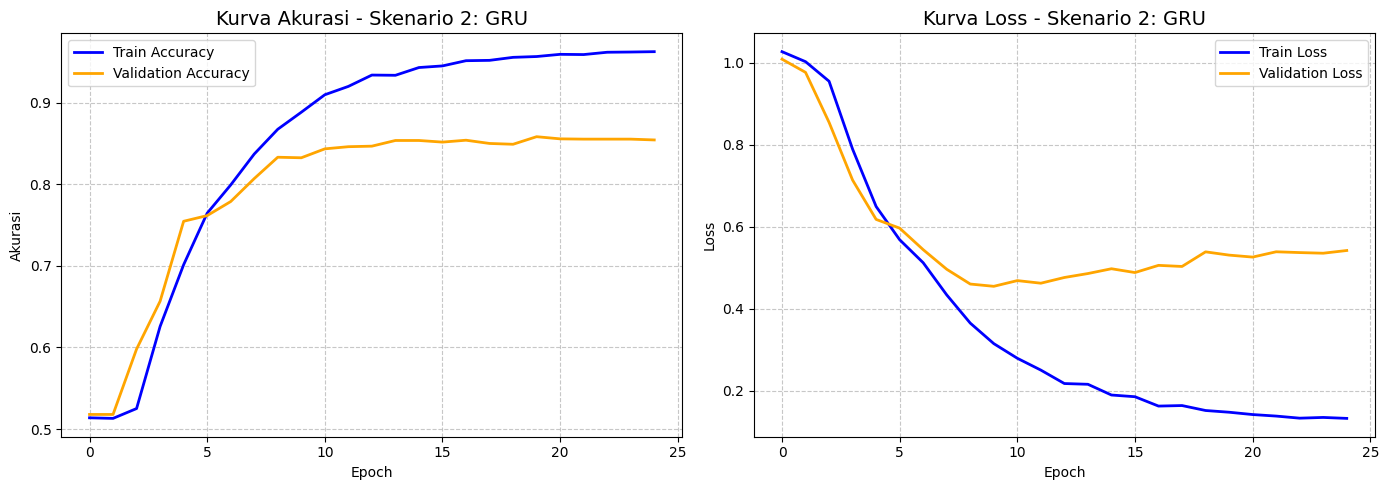

    - Final Test Loss     : 0.5307
    - Final Test Accuracy : 0.8585 (85.85%)

95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step

              precision    recall  f1-score   support

    negative       0.79      0.81      0.80       901
     neutral       0.94      0.83      0.88       554
    positive       0.87      0.90      0.88      1563

    accuracy                           0.86      3018
   macro avg       0.87      0.85      0.86      3018
weighted avg       0.86      0.86      0.86      3018



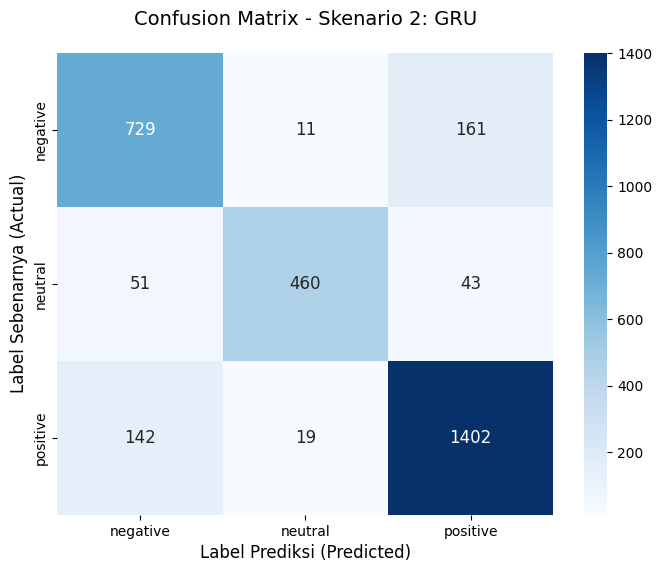

In [175]:
evaluate_deep_learning_model(
    model=model_gru,
    history=history_s2,
    X_test=X_test_pad_s2,
    y_test=y_test_s2,
    label_encoder=le,
    model_name="Skenario 2: GRU"
)

# SKENARIO 3: Bi-LSTM (70/30)



In [176]:
df_s3 = df.copy()
df_s3['final_text'] = df_s3['final_text'].fillna('neutral')

# SPLIT DATA 70/30
X_train_s3, X_test_s3, y_train_s3, y_test_s3 = train_test_split(
    df_s3['final_text'],
    df_s3["label_encoded"],
    test_size=0.3,
    random_state=123,
    stratify=df_s3["label_encoded"]
)

# TOKENIZER
max_vocab = 3000
max_length = 50

tok_s3 = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tok_s3.fit_on_texts(X_train_s1)

X_train_pad_s3 = pad_sequences(tok_s3.texts_to_sequences(X_train_s3), maxlen=max_length, padding='post', truncating='post')
X_test_pad_s3 = pad_sequences(tok_s3.texts_to_sequences(X_test_s3), maxlen=max_length, padding='post', truncating='post')

# MODEL Bi-LSTM
model_bilstm_s3 = Sequential([
    Embedding(input_dim=max_vocab, output_dim=64, input_length=max_length),
    SpatialDropout1D(0.4),
    Bidirectional(LSTM(32, return_sequences=False, dropout=0.3)),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model_bilstm_s3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

rlp_s3 = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

# CALLBACKS
es_s3 = EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True)
mc_s3 = ModelCheckpoint(filepath='best_bilstm_2.h5', monitor='val_accuracy', mode='max', save_best_only=True)

# TRAINING
history_s3 = model_bilstm_s3.fit(
    X_train_pad_s3, y_train_s3, epochs=30, batch_size=64,
    validation_data=(X_test_pad_s3, y_test_s3),
    callbacks=[es_s3, mc_s3, rlp_s3], verbose=1
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


110/111 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5105 - loss: 1.0099

111/111 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.5358 - loss: 0.9512 - val_accuracy: 0.6024 - val_loss: 0.8014 - learning_rate: 0.0010
Epoch 2/30
110/111 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6482 - loss: 0.7745

111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6744 - loss: 0.7364 - val_accuracy: 0.7429 - val_loss: 0.6074 - learning_rate: 0.0010
Epoch 3/30
110/111 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7739 - loss: 0.5745

...

111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.8411 - loss: 0.4411 - val_accuracy: 0.8188 - val_loss: 0.4620 - learning_rate: 0.0010
Epoch 5/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8580 - loss: 0.4018

111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.8681 - loss: 0.3774 - val_accuracy: 0.8360 - val_loss: 0.4576 - learning_rate: 0.0010
Epoch 6/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.8864 - loss: 0.3427 - val_accuracy: 0.8340 - val_loss: 0.4438 - learning_rate: 0.0010
Epoch 7/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9006 - loss: 0.3130

111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.9020 - loss: 0.3072 - val_accuracy: 0.8363 - val_loss: 0.4545 - learning_rate: 0.0010
Epoch 8/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9201 - loss: 0.2490

111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.9165 - loss: 0.2609 - val_accuracy: 0.8366 - val_loss: 0.4827 - learning_rate: 0.0010
Epoch 9/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9250 - loss: 0.2451 - val_accuracy: 0.8347 - val_loss: 0.5027 - learning_rate: 0.0010
Epoch 10/30
110/111 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9352 - loss: 0.2247

111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.9307 - loss: 0.2351 - val_accuracy: 0.8443 - val_loss: 0.5116 - learning_rate: 0.0010
Epoch 11/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.9374 - loss: 0.2175 - val_accuracy: 0.8277 - val_loss: 0.5528 - learning_rate: 0.0010
Epoch 12/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9398 - loss: 0.2120
Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9344 - loss: 0.2232 - val_accuracy: 0.8171 - val_loss: 0.5786 - learning_rate: 0.0010
Epoch 13/30
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.9301 - loss: 0.2247 - val_accuracy: 0.8353 - val_loss: 0.5594 - learning_rate: 5.0000e-04
Epoch 14/30
110/111 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9426 - loss: 0.1942
Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
111/111 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - accuracy: 0.9470 - loss: 0.17


       EVALUASI SKENARIO 3: BI-LSTM       



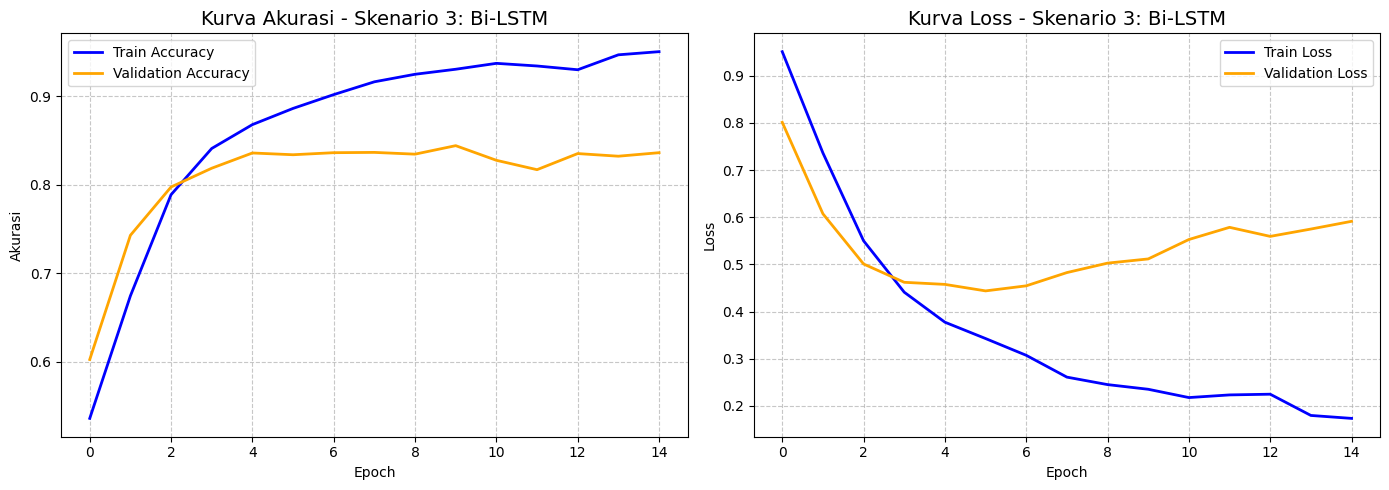

    - Final Test Loss     : 0.5116
    - Final Test Accuracy : 0.8443 (84.43%)

95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step

              precision    recall  f1-score   support

    negative       0.77      0.78      0.78       901
     neutral       0.89      0.84      0.86       554
    positive       0.87      0.88      0.88      1563

    accuracy                           0.84      3018
   macro avg       0.84      0.83      0.84      3018
weighted avg       0.84      0.84      0.84      3018



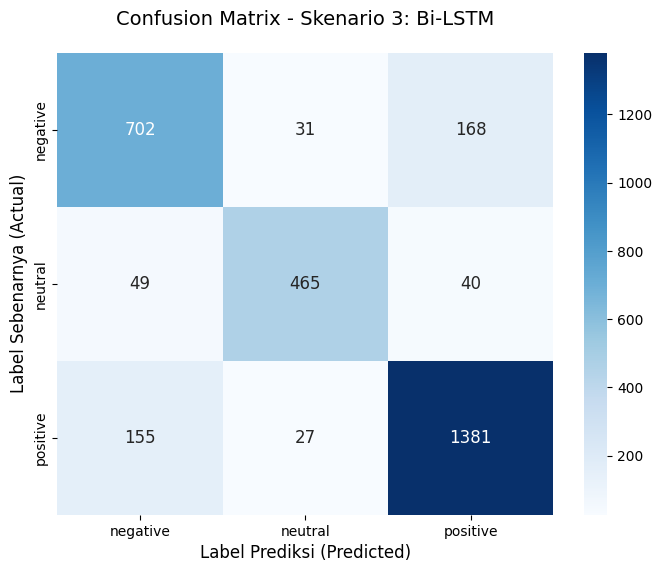

In [177]:
# Evaluasi Skenario 3 (Bi-LSTM)
evaluate_deep_learning_model(
    model=model_bilstm_s3,
    history=history_s3,
    X_test=X_test_pad_s3,
    y_test=y_test_s3,
    label_encoder=le,
    model_name="Skenario 3: Bi-LSTM"
)

# Comparison of All Models

In [178]:
train_acc_s1 = history_s1.history['accuracy'][-1]
train_acc_s2 = history_s2.history['accuracy'][-1]
train_acc_s3 = history_s3.history['accuracy'][-1]

test_acc_s1 = model_bilstm.evaluate(X_test_pad_s1, y_test_s1, verbose=0)[1]
test_acc_s2 = model_gru.evaluate(X_test_pad_s2, y_test_s2, verbose=0)[1]
test_acc_s3 = model_bilstm_s3.evaluate(X_test_pad_s3, y_test_s3, verbose=0)[1]

In [179]:
hasil_evaluasi = [
    {
        "Skenario": "Skema 1 (Bi-LSTM) 80/20",
        "Train Accuracy": train_acc_s1,
        "Test Accuracy": test_acc_s1
    },
    {
        "Skenario": "Skema 2 (GRU) 70/30",
        "Train Accuracy": train_acc_s2,
        "Test Accuracy": test_acc_s2
    },
    {
        "Skenario": "Skema 3 (Bi-LSTM) 70/30",
        "Train Accuracy": train_acc_s3,
        "Test Accuracy": test_acc_s3
    }
]

             TABEL PERBANDINGAN SKENARIO              


,Skenario,Train Accuracy,Test Accuracy
0,Skema 1 (Bi-LSTM) 80/20,0.946571,0.859841
1,Skema 2 (GRU) 70/30,0.962795,0.858516
2,Skema 3 (Bi-LSTM) 70/30,0.950582,0.844268


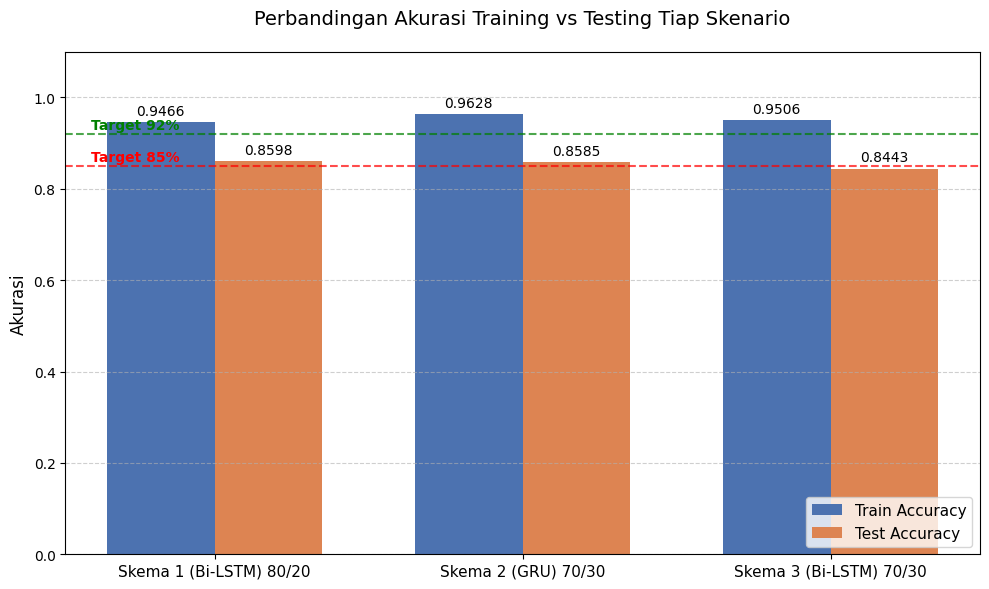

In [180]:
plot_model_comparison(hasil_evaluasi)

# Inference

In [192]:
model_name = 'best_bilstm.h5'
model = tf.keras.models.load_model(model_name)

def sentimen_prediksi(model, teks, tokenizer, max_len, label_encoder):
    # Preprocessing
    teks_bersih = cleaningText(str(teks))
    teks_final = casefoldingText(teks_bersih)

    # Tokenizer & Pad Sequences
    teks_seq = tokenizer.texts_to_sequences([teks_final])
    teks_pad = pad_sequences(teks_seq, maxlen=max_len, padding='post', truncating='post')

    # Prediksi
    pred_probabilitas = model.predict(teks_pad, verbose=0)

    # Cari nilai probabilitas tertinggi
    pred_index = np.argmax(pred_probabilitas, axis=1)

    # Kembalikan index menjadi nama label aslinya
    label_hasil = label_encoder.inverse_transform(pred_index)

    # Mengembalikan isi teksnya
    return label_hasil[0]

In [196]:
input_kalimat = [
    "This game is an absolute masterpiece! I enjoy every second of it.",
    "Worst update ever, the lag is unbearable and it keeps crashing.",
    "I just downloaded this game today, so far nothing special.",
    "I used to play this a lot, but the developers ruined the new update."
]

In [197]:
for teks in input_kalimat:
    hasil_tebakan = sentimen_prediksi(model, teks, tok_s1, max_length, le)
    print(f"Teks     : \n'{teks}'")
    print(f"Prediksi : \n{hasil_tebakan}")

Teks     : 
'This game is an absolute masterpiece! I enjoy every second of it.'
Prediksi : 
positive
Teks     : 
'Worst update ever, the lag is unbearable and it keeps crashing.'
Prediksi : 
negative
Teks     : 
'I just downloaded this game today, so far nothing special.'
Prediksi : 
positive
Teks     : 
'I used to play this a lot, but the developers ruined the new update.'
Prediksi : 
negative


model Bi-LSTM hasil skema 1 sudah mampu mengklasifikasikan sentimen yang jelas (Positif/Negatif) dengan sangat baik. Namun, model masih memiliki sedikit kelemahan pada kalimat yang bersifat netral.

Hal ini terjadi karena model cenderung memberikan bobot sangat tinggi pada kata-kata emosi kuat tertentu berdasarkan frekuensi kemunculannya di data latih seperti love dan special. Namun, dengan akurasi pengujian mencapai 85.98%, model ini sudah sangat layak dan terbukti berhasil menangkap pola dasar dari bahasa ulasan pemain.

# Requirements

In [184]:
pip freeze requirements.txt

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.4
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.51.3.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.3.30.0.54.34
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.38.0
bigquery-magics==0.12.2
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.2.25
c